Install and Data Handling

In [1]:
#Intalls

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from itertools import cycle
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras.datasets import fashion_mnist

#Fetching dataset
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

# Last 10,000 samples as test set

X_test = X[-10000:]
y_test = y[-10000:]

# Remaining 60,000 samples for training/validation

X_train_full = X[:-10000]
y_train_full = y[:-10000]

X = X / 255.0  # Normalize the data

y = y.astype(int)


Models and Analysis

In [2]:
#LOGISTIC REGRESSION

# Standardize the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
model.fit(X_train_full, y_train_full)

# Making predictions
y_pred = model.predict(X_test)

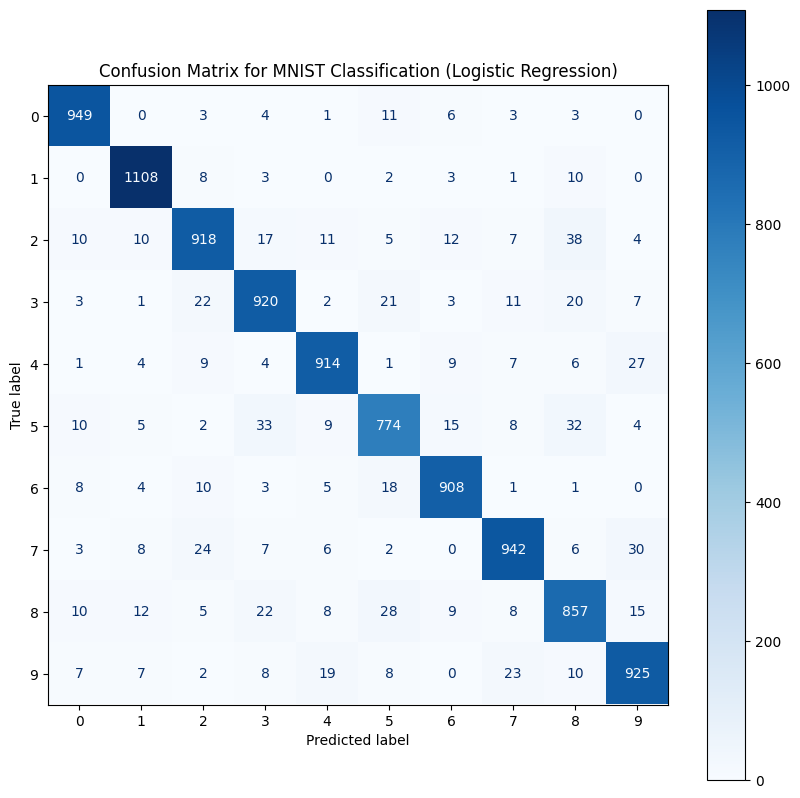

In [3]:
# Confusion Matrix heatmap

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
cmd.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for MNIST Classification (Logistic Regression)')
plt.show()

In [4]:
# Classificiation Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [5]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X / 255.0  # Normalize the data
y = y.astype(int)  # Convert labels to integers (no one-hot encoding)

# Reshape the data for CNN (28x28 pixels, 1 color channel)
X = X.values.reshape(-1, 28, 28, 1)

# Split into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=10000, random_state=23)

# Build the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_full, y_train_full, epochs=10, batch_size=128, validation_split=0.2)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


c:\Users\mikey\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8418 - loss: 0.5582 - val_accuracy: 0.9786 - val_loss: 0.0677
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9796 - loss: 0.0669 - val_accuracy: 0.9797 - val_loss: 0.0622
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9875 - loss: 0.0414 - val_accuracy: 0.9846 - val_loss: 0.0508
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9909 - loss: 0.0306 - val_accuracy: 0.9862 - val_loss: 0.0450
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9860 - val_loss: 0.0491
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9939 - loss: 0.0205 - val_accuracy: 0.9868 - val_loss: 0.0474
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9862 - val_loss: 0.0493
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


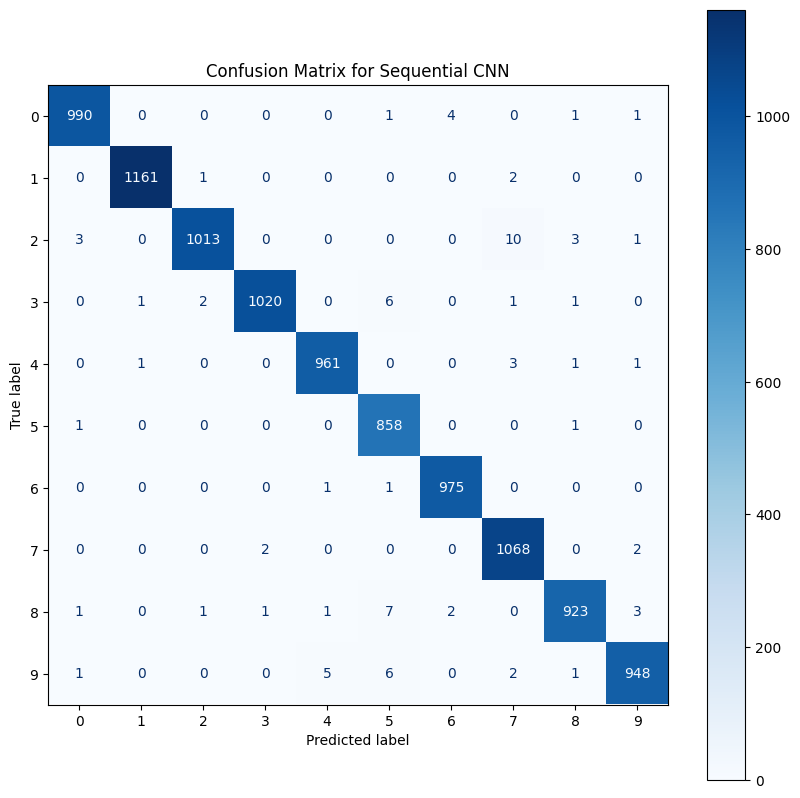

In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert predicted probabilities to class labels (integer)
y_pred_classes = np.argmax(y_pred, axis=1)

# y_test is already in integer format, so we don't need to apply np.argmax
y_true = y_test

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
cmd.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Sequential CNN')
plt.show()

In [7]:
# Classificiation Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       997
           1       1.00      1.00      1.00      1164
           2       1.00      0.98      0.99      1030
           3       1.00      0.99      0.99      1031
           4       0.99      0.99      0.99       967
           5       0.98      1.00      0.99       860
           6       0.99      1.00      1.00       977
           7       0.98      1.00      0.99      1072
           8       0.99      0.98      0.99       939
           9       0.99      0.98      0.99       963

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




Classification Report for LDA:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       997
           1       0.88      0.96      0.92      1164
           2       0.90      0.80      0.84      1030
           3       0.85      0.83      0.84      1031
           4       0.86      0.90      0.88       967
           5       0.81      0.81      0.81       860
           6       0.92      0.91      0.91       977
           7       0.93      0.85      0.89      1072
           8       0.79      0.80      0.80       939
           9       0.80      0.86      0.83       963

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



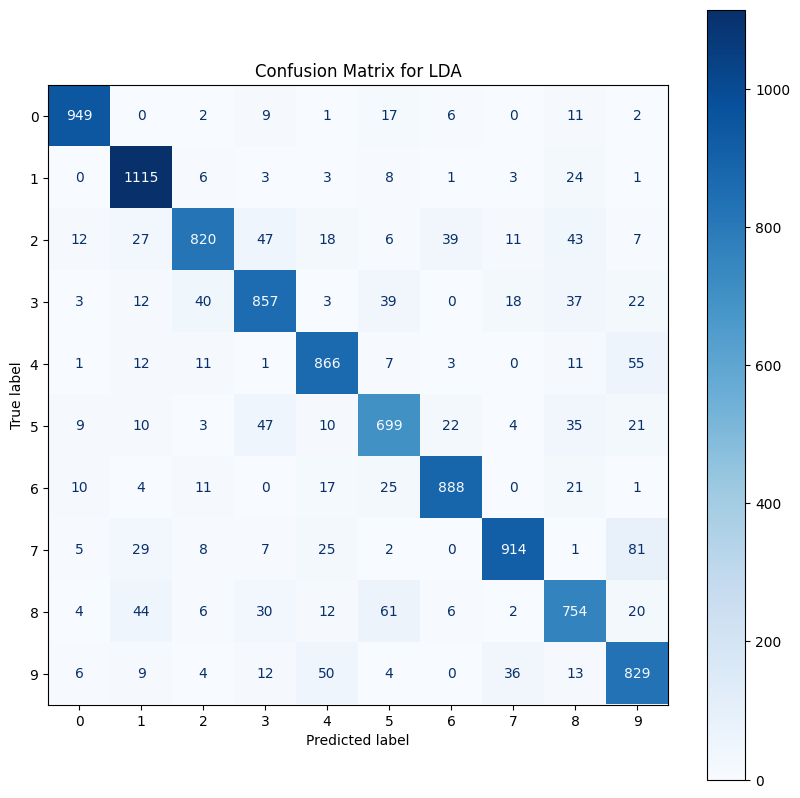

In [8]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X / 255.0  # Normalize the data
y = y.astype(int)  # Convert labels to integers

# Reshape the data for models
X = X.values.reshape(-1, 28 * 28)  # Flatten the images for models

# Split into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=10000, random_state=23)

# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_full, y_train_full)
y_pred_lda = lda.predict(X_test)

# Confusion Matrix and Classification Report
print("\nClassification Report for LDA:")
print(classification_report(y_test, y_pred_lda))

cm_lda = confusion_matrix(y_test, y_pred_lda)
fig, ax = plt.subplots(figsize=(10, 10))
cmd_lda = ConfusionMatrixDisplay(cm_lda, display_labels=np.arange(10))
cmd_lda.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for LDA')
plt.show()


Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6225
           1       0.94      0.98      0.96      7120
           2       0.88      0.91      0.90      6263
           3       0.88      0.89      0.88      6418
           4       0.90      0.93      0.91      6167
           5       0.88      0.85      0.87      5697
           6       0.95      0.94      0.95      6176
           7       0.93      0.92      0.92      6549
           8       0.91      0.84      0.87      6114
           9       0.91      0.86      0.88      6271

    accuracy                           0.91     63000
   macro avg       0.91      0.91      0.91     63000
weighted avg       0.91      0.91      0.91     63000



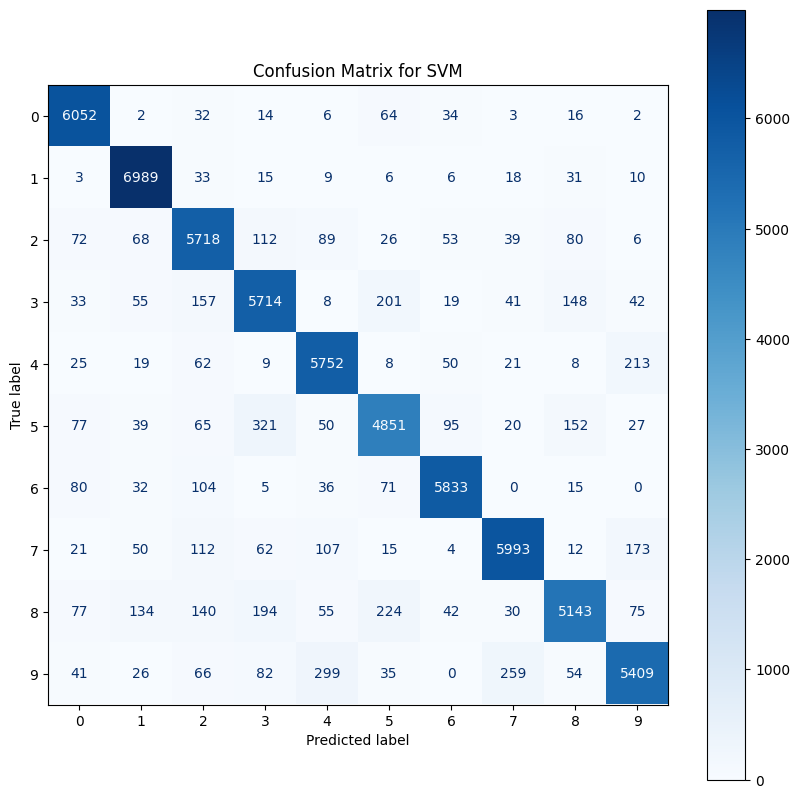

In [9]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X, y, test_size=0.9, random_state=23)

svm = SVC(kernel='linear', random_state=23)  # Linear kernel as it is the least computationally intense
svm.fit(X_train_svm, y_train_svm)
y_pred_svm = svm.predict(X_test_svm)

# Confusion Matrix and Classification Report
print("\nClassification Report for SVM:")
print(classification_report(y_test_svm, y_pred_svm))

cm_svm = confusion_matrix(y_test_svm, y_pred_svm)
fig, ax = plt.subplots(figsize=(10, 10))
cmd_svm = ConfusionMatrixDisplay(cm_svm, display_labels=np.arange(10))
cmd_svm.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for SVM')
plt.show()


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       997
           1       0.95      0.96      0.95      1164
           2       0.88      0.86      0.87      1030
           3       0.84      0.81      0.83      1031
           4       0.87      0.87      0.87       967
           5       0.82      0.82      0.82       860
           6       0.90      0.91      0.90       977
           7       0.91      0.91      0.91      1072
           8       0.81      0.82      0.82       939
           9       0.83      0.84      0.84       963

    accuracy                           0.88     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.88      0.88      0.88     10000



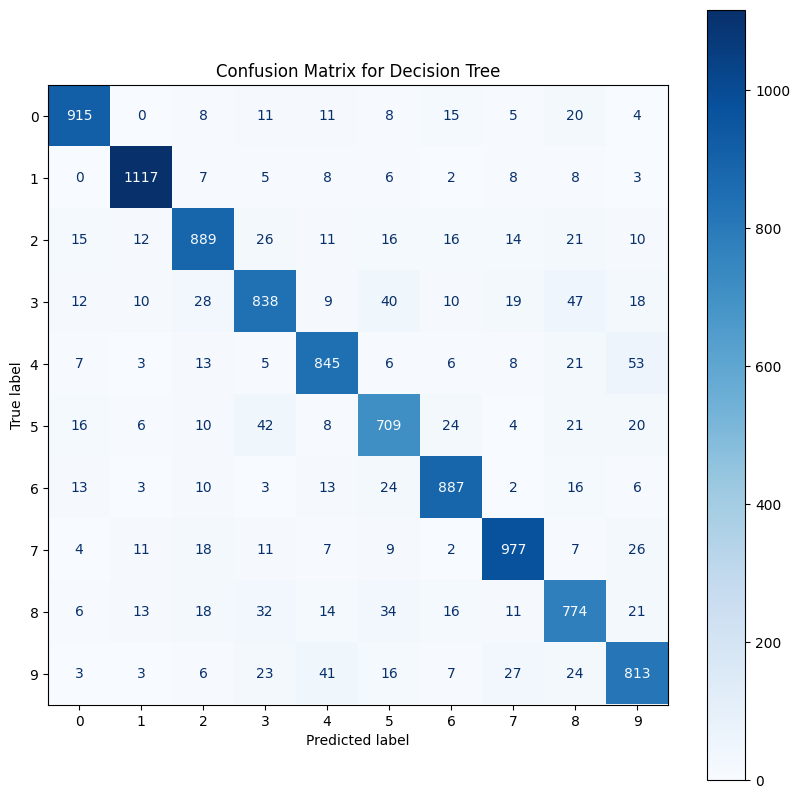

In [10]:
dt = DecisionTreeClassifier(random_state=23)
dt.fit(X_train_full, y_train_full)
y_pred_dt = dt.predict(X_test)

# Confusion Matrix and Classification Report
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(10, 10))
cmd_dt = ConfusionMatrixDisplay(cm_dt, display_labels=np.arange(10))
cmd_dt.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.show()


Epoch 1/10


c:\Users\mikey\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7971 - loss: 0.6994 - val_accuracy: 0.9680 - val_loss: 0.1086
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9727 - loss: 0.0949 - val_accuracy: 0.9781 - val_loss: 0.0722
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9804 - loss: 0.0649 - val_accuracy: 0.9801 - val_loss: 0.0636
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0476 - val_accuracy: 0.9833 - val_loss: 0.0530
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9850 - val_loss: 0.0478
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9904 - loss: 0.0294 - val_accuracy: 0.9838 - val_loss: 0.0537
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9926 - loss: 0.0249 - val_accuracy: 0.9857 - val_loss: 0.0506
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9946 - loss: 0.0183 - val_accuracy: 0.9862 - val_

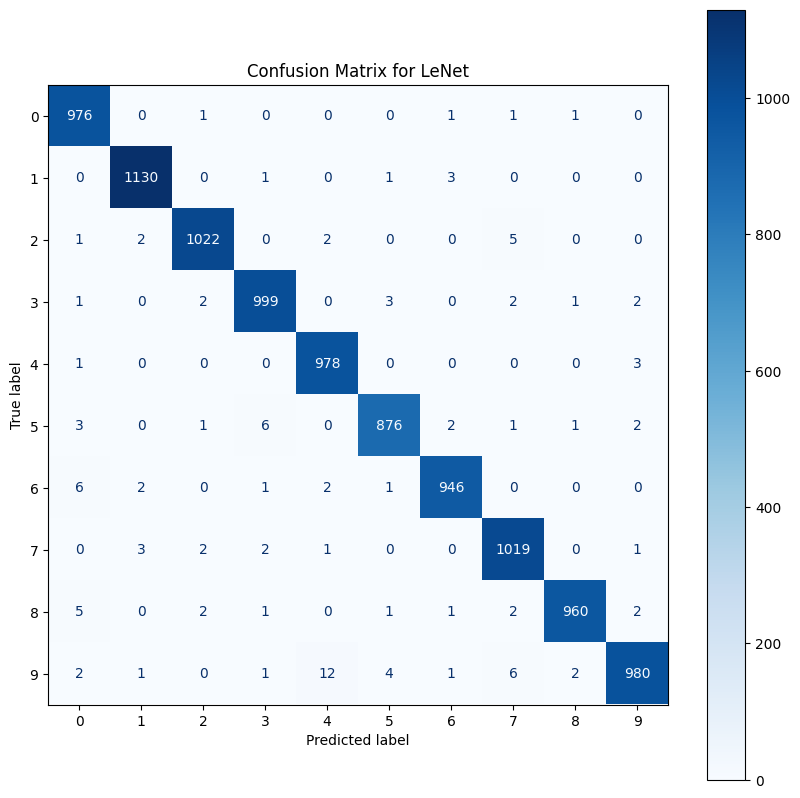

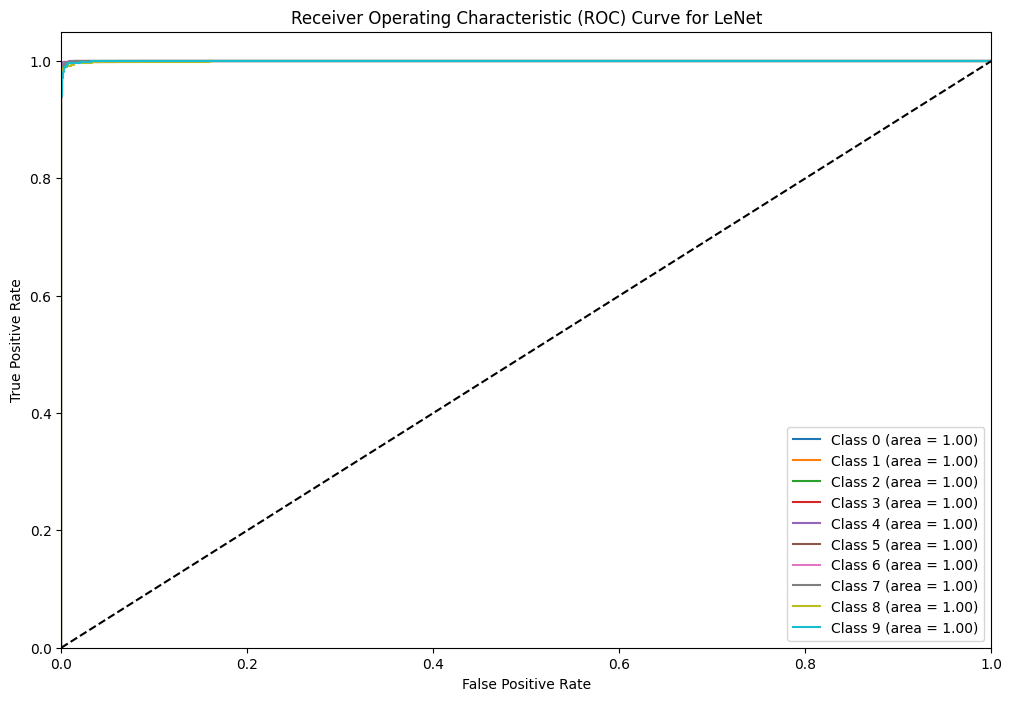

In [11]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# LeNet model
model_lenet = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

model_lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lenet.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate
y_pred_lenet = model_lenet.predict(X_test)
y_pred_classes_lenet = np.argmax(y_pred_lenet, axis=1)
y_true_lenet = np.argmax(y_test, axis=1)

# Classification report and confusion matrix
print("\nClassification Report for LeNet:")
print(classification_report(y_true_lenet, y_pred_classes_lenet))

cm_lenet = confusion_matrix(y_true_lenet, y_pred_classes_lenet)
fig, ax = plt.subplots(figsize=(10, 10))
cmd_lenet = ConfusionMatrixDisplay(cm_lenet, display_labels=np.arange(10))
cmd_lenet.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for LeNet')
plt.show()

y_test_binarized = label_binarize(np.argmax(y_test, axis=1), classes=np.arange(10))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_lenet[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for LeNet')
plt.legend(loc="lower right")
plt.show()

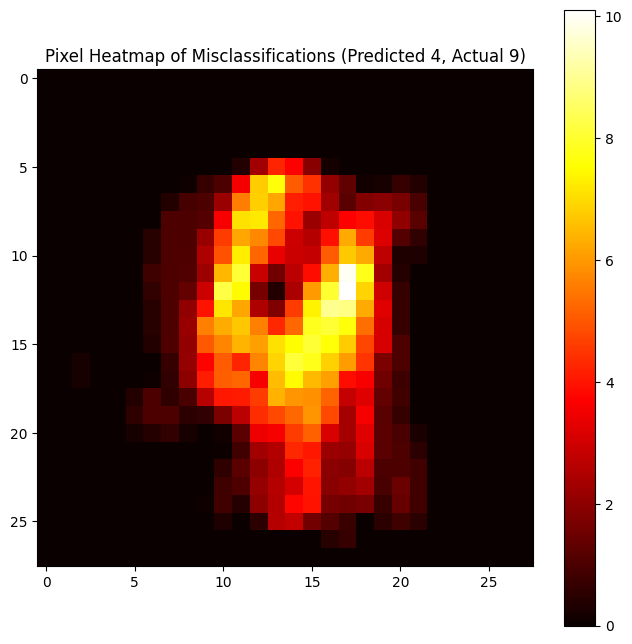

In [12]:
misclassified_indices = np.where((y_pred_classes_lenet == 4) & (y_true_lenet == 9))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 4, Actual 9)')
plt.show()

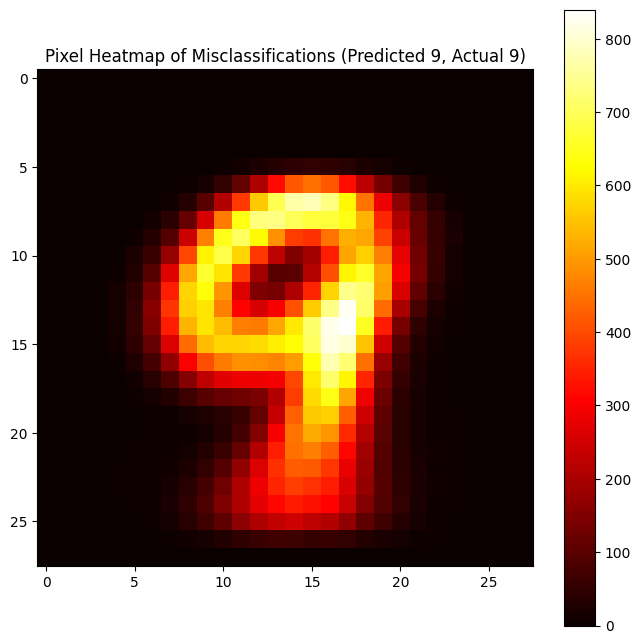

In [13]:
misclassified_indices = np.where((y_pred_classes_lenet == 9) & (y_true_lenet == 9))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 9, Actual 9)')
plt.show()

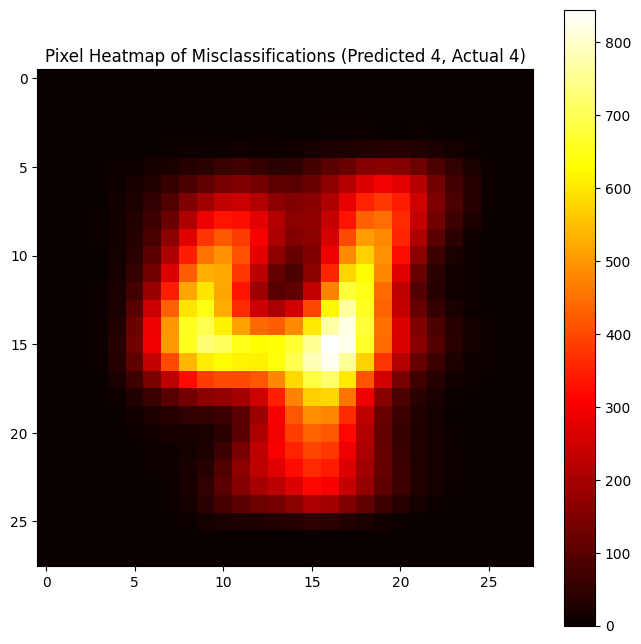

In [14]:
misclassified_indices = np.where((y_pred_classes_lenet == 4) & (y_true_lenet == 4))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 4, Actual 4)')
plt.show()

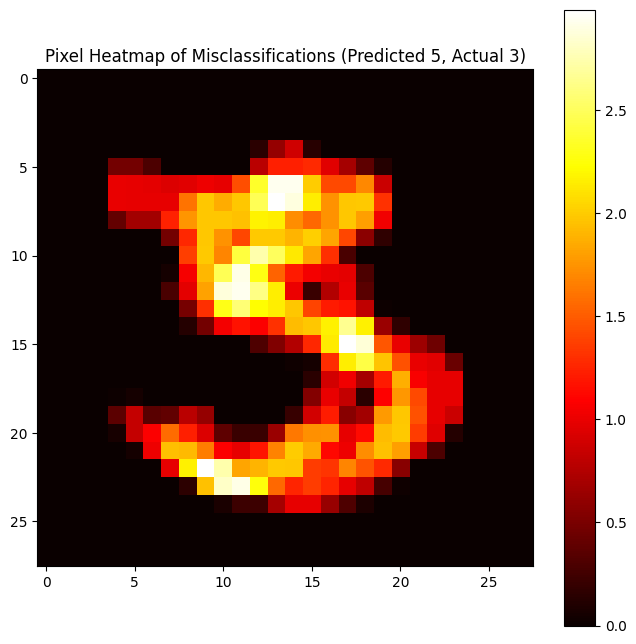

In [15]:
misclassified_indices = np.where((y_pred_classes_lenet == 5) & (y_true_lenet == 3))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 5, Actual 3)')
plt.show()

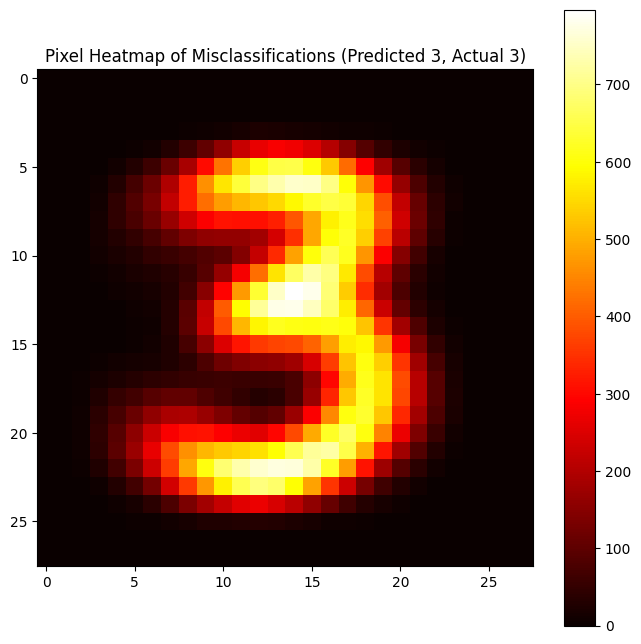

In [16]:
misclassified_indices = np.where((y_pred_classes_lenet == 3) & (y_true_lenet == 3))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 3, Actual 3)')
plt.show()

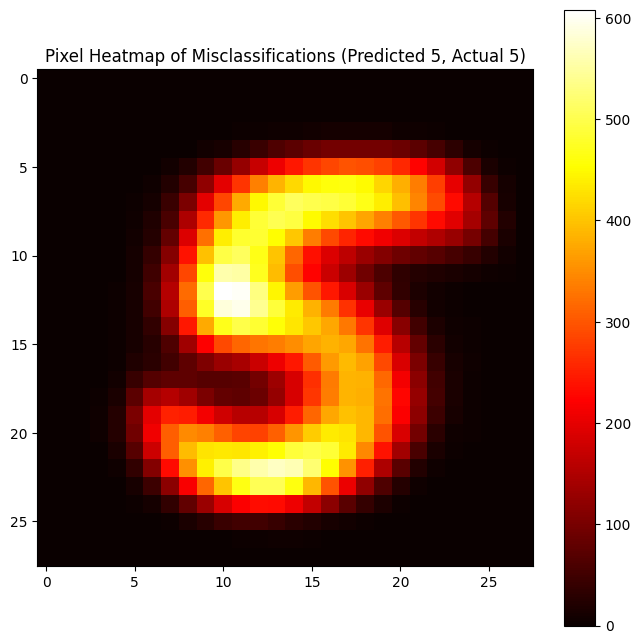

In [17]:
misclassified_indices = np.where((y_pred_classes_lenet == 5) & (y_true_lenet == 5))[0]

# Sum the images to create a heatmap
heatmap = np.sum(X_test[misclassified_indices], axis=0).reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(8, 8))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Pixel Heatmap of Misclassifications (Predicted 5, Actual 5)')
plt.show()